In [77]:
import yfinance as yf
import pandas as pd

data = yf.download("GC=F", start="2010-01-01", progress=False)
data = data[['Close']]
data = data.dropna()

print(data.head())
print(data.shape)

Price             Close
Ticker             GC=F
Date                   
2010-01-04  1117.699951
2010-01-05  1118.099976
2010-01-06  1135.900024
2010-01-07  1133.099976
2010-01-08  1138.199951
(4077, 1)


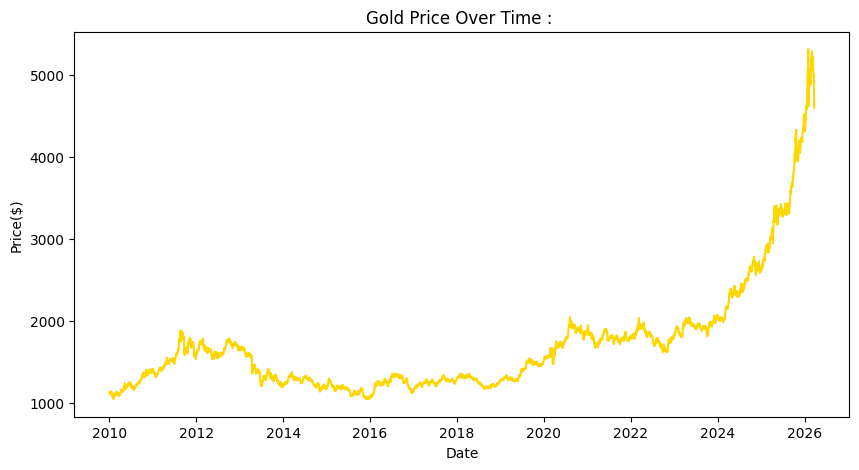

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(data["Close"],color='gold')
plt.title("Gold Price Over Time : ")
plt.xlabel("Date")
plt.ylabel("Price($)")
plt.show()

In [79]:
from sklearn.preprocessing import MinMaxScaler 

split = int(len(data) * 0.8)
train_data = data[:split]

scaler = MinMaxScaler(feature_range=(0,1))
scaler.fit(train_data)

scaled_data = scaler.transform(data)

print(scaled_data[:5])

[[0.06685311]
 [0.06725285]
 [0.08504045]
 [0.08224236]
 [0.08733877]]


In [80]:
import numpy as np

x = []
y = []

input_days = 60
output_days = 7

for i in range (len(scaled_data) - input_days - output_days) :
    x.append(scaled_data[i : i + input_days])
    y.append(scaled_data[i + input_days : i + input_days + output_days])

x = np.array(x)
y = np.array(y)

print("X shape:", x.shape)
print("Y shape:", y.shape)

X shape: (4010, 60, 1)
Y shape: (4010, 7, 1)


In [81]:
split = int(len(x) * 0.8)

x_train = x[:split]
y_train = y[:split]

x_test = x[split:]
y_test = y[split:]

print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)

(3208, 60, 1) (802, 60, 1)
(3208, 7, 1) (802, 7, 1)


In [82]:
y_train = y_train.reshape(y_train.shape[0], y_train.shape[1])
y_test = y_test.reshape(y_test.shape[0], y_test.shape[1])

print(y_train.shape, y_test.shape)

(3208, 7) (802, 7)


In [84]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(input_days,1)),
    Dropout(0.1),
    LSTM(32),
    Dense(output_days)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,543 (115.40 KB)

 Trainable params: 29,543 (115.40 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - loss: 0.0207 - val_loss: 1.0920
Epoch 2/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0023 - val_loss: 0.9942
Epoch 3/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0021 - val_loss: 0.9183
Epoch 4/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0020 - val_loss: 0.8644
Epoch 5/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 0.0019 - val_loss: 0.8052
Epoch 6/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 0.0018 - val_loss: 0.7826
Epoch 7/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0017 - val_loss: 0.7551
Epoch 8/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0017 - val_loss: 0.7032
Epoch 9/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0017 - val_loss: 0.7164
Epoch 10/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0016 - val_loss: 0.6687
Epoch 11/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0015 - val_loss: 0.6612
Epoch 12/150
101/101 ━━━━━━━━━

In [86]:
predictions = model.predict(x_test)
print(predictions.shape)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
(802, 7)


In [87]:
predictions_reshaped = predictions.reshape(-1, 1)
y_test_reshaped = y_test.reshape(-1, 1)

predictions_inv = scaler.inverse_transform(predictions_reshaped)
y_test_inv = scaler.inverse_transform(y_test_reshaped)

predictions_inv = predictions_inv.reshape(predictions.shape)
y_test_inv = y_test_inv.reshape(y_test.shape)

print(predictions_inv[:1])

[[1836.443  1836.7491 1841.3595 1839.5243 1840.4344 1835.1866 1828.4755]]


In [88]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_inv.flatten(), predictions_inv.flatten())

print(f"📉 MAE: {mae:.2f}")
print(f"👉 This means the model is off by approximately ${mae:.2f} on average.")

📉 MAE: 368.77
👉 This means the model is off by approximately $368.77 on average.


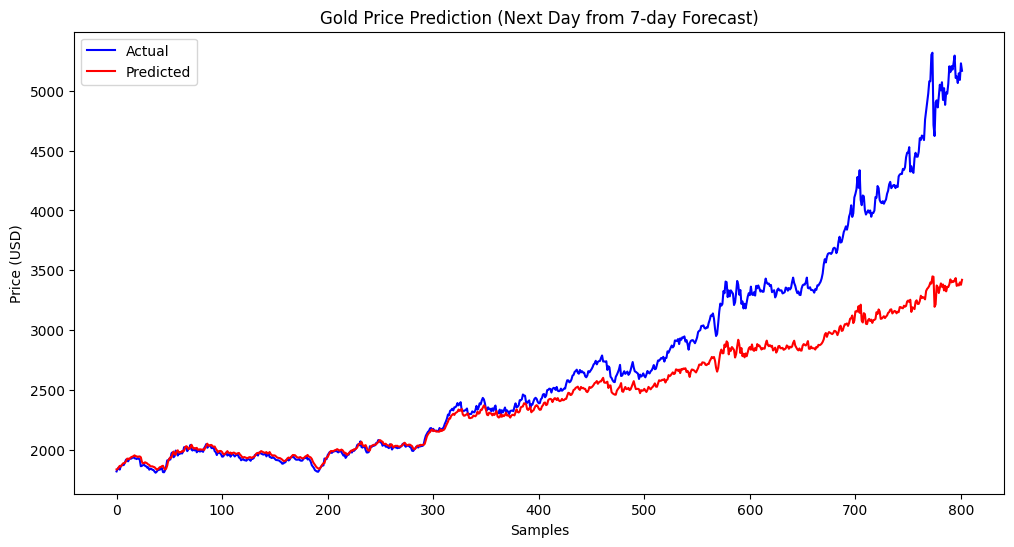

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test_inv[:, 0], label='Actual', color='blue')
plt.plot(predictions_inv[:, 0], label='Predicted', color='red')
plt.title("Gold Price Prediction (Next Day from 7-day Forecast)")
plt.xlabel("Samples")
plt.ylabel("Price (USD)")
plt.legend()

plt.show()